# These commands are helpful to see astroquery version and relevant steuptools


In [47]:
#import pkg_resources
#print(pkg_resources.__file__)
#pip install setuptools
#import sys
#print(sys.executable)
#print(sys.version)

# Import Libraries

In [1]:
from astroquery.alma import Alma
import os
import numpy as np
import pandas as pd
from astroquery.alma.utils import parse_frequency_support
import astropy.units as u
from astropy.table import Table
import shutil
from pathlib import Path
import tarfile
from astropy.io import fits
from spectral_cube import SpectralCube
import matplotlib.pyplot as plt 
import alminer
from astropy.wcs import WCS
from astropy.visualization.wcsaxes import add_beam

# Edit this for relevant molecualr line

In [2]:
sio_rest = 347.330581 * u.GHz #Splatalouge SiO (8-7)

#CO_rest = 345.7959899 * u.GHz #CO (3-2)

# These are the same keywords on the ALMA Archive: 1) Disks around low-mass stars, 2) Low mass star formation, 3) Outflows, jets, and ionized winds

In [3]:

# Give me all columns from the database. We are searching rowns with ALMA metadata
alma = Alma()
alma.archive_url = 'https://almascience.eso.org'

# Use ALMA AstroTAP query to find the dataproducts with observation keywords stored in ALMA data

In [4]:

query = """
SELECT
    obs_publisher_did,
    member_ous_uid,
    target_name,
    frequency_support,
    science_keyword
FROM ivoa.obscore
WHERE dataproduct_type = 'cube'
AND (
      science_keyword LIKE '%jets and ionized winds%'
      
    
  )
"""

# Results with all the ALMA dataproducts

In [5]:
#This results have all the data products
results = alma.query_tap(query)

In [6]:
#pd.DataFrame(results)

# Parse the frequency support in the ALMA Data

In [7]:
#Freuency support stored as string so need to parse frequncy and only need frequncy ranges
frequency_support_str = results['frequency_support'][:1]
print(frequency_support_str)
print(type(frequency_support_str))

['[345.56..345.68GHz,141.11kHz,13.1mJy/beam@10km/s,4mJy/beam@native, XX YY] U [345.75..345.87GHz,141.11kHz,13mJy/beam@10km/s,4mJy/beam@native, XX YY] U [346.95..347.07GHz,141.11kHz,12.8mJy/beam@10km/s,3.9mJy/beam@native, XX YY] U [347.28..347.41GHz,141.11kHz,12.8mJy/beam@10km/s,3.9mJy/beam@native, XX YY] U [356.07..358.06GHz,31250.00kHz,14.8mJy/beam@10km/s,1.1mJy/beam@native, XX YY] U [356.68..356.81GHz,121.15kHz,14.9mJy/beam@10km/s,4.6mJy/beam@native, XX YY]']
<class 'numpy.ma.MaskedArray'>


In [8]:
#Parse the frequncy support
for a in range(len(frequency_support_str)):
    freq_ranges = parse_frequency_support(frequency_support_str[a])
    print(freq_ranges,a)
    

[[345.56 345.68]
 [345.75 345.87]
 [346.95 347.07]
 [347.28 347.41]
 [356.07 358.06]
 [356.68 356.81]] GHz 0


# Setup a frequency range to only find relevant data products with respect to the rest frequency

In [9]:
# Set up frequency range and in results find the range

matches = [] #Empty list
#print(type(results))
for ind,x in enumerate(results):
    #if ind >= 2:
        #continue
    ranges = parse_frequency_support(x['frequency_support'])
    #print(ranges)

    for fmin, fmax in ranges:
        if sio_rest >= fmin and sio_rest <= fmax:
            matches.append(x)
            break
print(len(matches))

1313


In [10]:
#convert results to a table
table = results.to_table()

In [11]:
#print columnames
table.colnames

['obs_publisher_did',
 'member_ous_uid',
 'target_name',
 'frequency_support',
 'science_keyword']

# Found Matches within the frequency range

In [12]:
# Convert list to a astropy.table
matches = Table(rows=matches, names=table.colnames)
print(len(matches))

1313


In [13]:
print(matches)

     obs_publisher_did      ...
--------------------------- ...
ADS/JAO.ALMA#2023.1.01515.S ...
ADS/JAO.ALMA#2023.1.01515.S ...
ADS/JAO.ALMA#2023.1.01515.S ...
ADS/JAO.ALMA#2023.1.01515.S ...
ADS/JAO.ALMA#2023.1.01515.S ...
ADS/JAO.ALMA#2023.1.01515.S ...
ADS/JAO.ALMA#2023.1.01515.S ...
ADS/JAO.ALMA#2023.1.01515.S ...
ADS/JAO.ALMA#2023.1.01515.S ...
ADS/JAO.ALMA#2023.1.01515.S ...
                        ... ...
ADS/JAO.ALMA#2019.1.00299.S ...
ADS/JAO.ALMA#2019.1.00299.S ...
ADS/JAO.ALMA#2019.1.00299.S ...
ADS/JAO.ALMA#2019.1.00299.S ...
ADS/JAO.ALMA#2018.1.01162.S ...
ADS/JAO.ALMA#2018.1.01162.S ...
ADS/JAO.ALMA#2018.1.01162.S ...
ADS/JAO.ALMA#2018.1.01162.S ...
ADS/JAO.ALMA#2018.1.01162.S ...
ADS/JAO.ALMA#2018.1.01162.S ...
Length = 1313 rows


In [21]:
subset = 0

In [22]:
print(matches['member_ous_uid'][subset])

uid://A001/X3621/X98e


# Expand the files infromation

In [43]:
uid = matches['member_ous_uid'][subset]

products = alma.get_data_info (uid,expand_tarfiles=True)

print(products)

                        ID                         ... link_authorized
                                                   ...                
-------------------------------------------------- ... ---------------
                             uid://A001/X3621/X98e ...            True
                             uid://A001/X3621/X98e ...            True
                             uid://A001/X3621/X98e ...            True
                             uid://A001/X3621/X98e ...            True
                             uid://A001/X3621/X98e ...            True
                             uid://A001/X3621/X98e ...            True
                             uid://A001/X3621/X98e ...            True
                             uid://A001/X3621/X98e ...            True
                             uid://A001/X3621/X98e ...            True
                                               ... ...             ...
2023.1.01515.S_uid___A001_X3621_X98e_auxiliary.tar ...            True
2023.1

# Only selecting tar file contain science products

In [44]:

science_tar = products[
    [('001_of_001.tar' in str(x)) for x in products['access_url']]
]

#print(len(science_tar))
print(science_tar)

          ID          ... link_authorized
                      ...                
--------------------- ... ---------------
uid://A001/X3621/X98e ...            True


# Expand tar file and only select cube data products

In [45]:
cube_files = []

for row in products:
    if 'cube' in str(row).lower() and '.fits' in str(row).lower():
        cube_files.append(row)
        print(row)

for x in cube_files:
    print(len(x))

                         ID                                                                        access_url                                                service_def error_message semantics local_semantics                     description                       content_type   content_length content_qualifier link_auth link_authorized
                                                                                                                                                                                                                                                                                           byte                                                 
--------------------------------------------------- -------------------------------------------------------------------------------------------------------- ----------- ------------- --------- --------------- --------------------------------------------------- ---------------- -------------- ----------------- --------- -----

# Download Data

In [72]:
alma.cache_location = '/Users/skaur/Machine-Learning-Project/Astromorph_project/alma_TAP/scratch_files' #save fits file to that location
download_dir = Path("/Users/skaur/Machine-Learning-Project/Astromorph_project/alma_TAP/scratch_files")
download_dir.mkdir(exist_ok=True)

# Check available columns
#print(cube_files.colnames)

# Download selected files
downloaded_files = alma.download_files(
    [row['access_url'] for row in cube_files]
)
# Move files
for f in downloaded_files:
    shutil.move(f, download_dir / Path(f).name)

In [49]:
#print(downloaded_files)

['/users/skaur/Machine-Learning-Project/Astromorph_project/alma_astroquery/alma_TAP/scratch_files/member.uid___A001_X3621_X98e.DHNb72_sci.spw16.cube.I.mask.fits.gz', '/users/skaur/Machine-Learning-Project/Astromorph_project/alma_astroquery/alma_TAP/scratch_files/member.uid___A001_X3621_X98e.DHNb72_sci.spw16.cube.I.pb.fits.gz', '/users/skaur/Machine-Learning-Project/Astromorph_project/alma_astroquery/alma_TAP/scratch_files/member.uid___A001_X3621_X98e.DHNb72_sci.spw16.cube.I.pbcor.fits', '/users/skaur/Machine-Learning-Project/Astromorph_project/alma_astroquery/alma_TAP/scratch_files/member.uid___A001_X3621_X98e.DHNb72_sci.spw18.cube.I.mask.fits.gz', '/users/skaur/Machine-Learning-Project/Astromorph_project/alma_astroquery/alma_TAP/scratch_files/member.uid___A001_X3621_X98e.DHNb72_sci.spw18.cube.I.pb.fits.gz', '/users/skaur/Machine-Learning-Project/Astromorph_project/alma_astroquery/alma_TAP/scratch_files/member.uid___A001_X3621_X98e.DHNb72_sci.spw18.cube.I.pbcor.fits', '/users/skaur/Mac

In [50]:
#print(download_dir.resolve())
#print(alma.cache_location)

/Users/skaur/Machine-Learning-Project/Astromorph_project/scratch_files
/users/skaur/Machine-Learning-Project/Astromorph_project/alma_astroquery/alma_TAP/scratch_files


In [48]:
#print(download_dir.exists())
#p = Path("/users/skaur/Machine-Learning-Project/Astromorph_project/alma_astroquery/alma_TAP/scratch_files")
#print(p.exists())

True
True


In [48]:
#Alma.help_tap()

# Get Rest Frequency for all fits files

In [73]:
for f in download_dir.glob("*.fits"):
    if "cube" in f.name.lower():
        header = fits.getheader(f)

        print("\n", f.name)
        print("Rest frequency:", header.get("RESTFRQ", "No RESTFRQ"))


 member.uid___A001_X3621_X98e.DHNb72_sci.spw24.cube.I.pbcor.fits
Rest frequency: 357050000000.0

 member.uid___A001_X3621_X98e.DHNb72_sci.spw20.cube.I.pbcor.fits
Rest frequency: 347330578600.0

 member.uid___A001_X3621_X98e.DHNb72_sci.spw26.cube.I.pbcor.fits
Rest frequency: 356734242000.0

 member.uid___A001_X3621_X98e.DHNb72_sci.spw22.cube.I.pbcor.fits
Rest frequency: 346998347000.0

 member.uid___A001_X3621_X98e.DHNb72_sci.spw16.cube.I.pbcor.fits
Rest frequency: 345795990000.0

 member.uid___A001_X3621_X98e.DHNb72_sci.spw18.cube.I.pbcor.fits
Rest frequency: 345609010000.0


# Filter the fits files and only select file with respect to the rest frequency

In [74]:
#Use rest frequency to find the right sio cube fits file
sio_file = None

for f in download_dir.glob("*.fits"):

    header = fits.getheader(f)

    restfreq = header.get("RESTFRQ", header.get("RESTFREQ", None))

    if restfreq is not None:
        restfreq_GHz = restfreq / 1e9

        if 346 < restfreq_GHz < 348:
            sio_file = f
            break

print("SiO file:", sio_file)
#print(header)

SiO file: /Users/skaur/Machine-Learning-Project/Astromorph_project/alma_TAP/scratch_files/member.uid___A001_X3621_X98e.DHNb72_sci.spw20.cube.I.pbcor.fits


# Look all files in the download folder

In [75]:
import glob
all_files = glob.glob("./alma_TAP/scratch_files/*.fits*")
all_files

['./alma_TAP/scratch_files/member.uid___A001_X3621_X98e.DHNb72_sci.spw24.cube.I.pbcor.fits',
 './alma_TAP/scratch_files/member.uid___A001_X3621_X98e.DHNb72_sci.spw18.cube.I.pb.fits.gz',
 './alma_TAP/scratch_files/member.uid___A001_X3621_X98e.DHNb72_sci.spw16.cube.I.mask.fits.gz',
 './alma_TAP/scratch_files/member.uid___A001_X3621_X98e.DHNb72_sci.spw20.cube.I.pbcor.fits',
 './alma_TAP/scratch_files/member.uid___A001_X3621_X98e.DHNb72_sci.spw26.cube.I.pbcor.fits',
 './alma_TAP/scratch_files/member.uid___A001_X3621_X98e.DHNb72_sci.spw22.cube.I.pbcor.fits',
 './alma_TAP/scratch_files/member.uid___A001_X3621_X98e.DHNb72_sci.spw18.cube.I.mask.fits.gz',
 './alma_TAP/scratch_files/member.uid___A001_X3621_X98e.DHNb72_sci.spw16.cube.I.pbcor.fits',
 './alma_TAP/scratch_files/member.uid___A001_X3621_X98e.DHNb72_sci.spw26.cube.I.pb.fits.gz',
 './alma_TAP/scratch_files/member.uid___A001_X3621_X98e.DHNb72_sci.spw16.cube.I.pb.fits.gz',
 './alma_TAP/scratch_files/member.uid___A001_X3621_X98e.DHNb72_sci

In [83]:
#var = './alma_TAP/scratch_files/member.uid___A001_X3621_X98e.DHNb72_sci.spw20.cube.I.pbcor.fits'
var = './'+str(sio_file)
mask_file = var.split('pbcor.fits')[0]+'mask.fits.gz'
pb_file = var.split('pbcor.fits')[0] +'pb.fits.gz'

In [84]:
keep_files = []
keep_files.append(var)
keep_files.append(mask_file)
keep_files.append(pb_file)
print(keep_files)


['./alma_TAP/scratch_files/member.uid___A001_X3621_X98e.DHNb72_sci.spw20.cube.I.pbcor.fits', './alma_TAP/scratch_files/member.uid___A001_X3621_X98e.DHNb72_sci.spw20.cube.I.mask.fits.gz', './alma_TAP/scratch_files/member.uid___A001_X3621_X98e.DHNb72_sci.spw20.cube.I.pb.fits.gz']


In [85]:
print("keep_files:")
for f in keep_files:
    print(repr(f))

print("\nall_files:")
for f in all_files:
    print(repr(f))

keep_files:
'./alma_TAP/scratch_files/member.uid___A001_X3621_X98e.DHNb72_sci.spw20.cube.I.pbcor.fits'
'./alma_TAP/scratch_files/member.uid___A001_X3621_X98e.DHNb72_sci.spw20.cube.I.mask.fits.gz'
'./alma_TAP/scratch_files/member.uid___A001_X3621_X98e.DHNb72_sci.spw20.cube.I.pb.fits.gz'

all_files:
'./alma_TAP/scratch_files/member.uid___A001_X3621_X98e.DHNb72_sci.spw24.cube.I.pbcor.fits'
'./alma_TAP/scratch_files/member.uid___A001_X3621_X98e.DHNb72_sci.spw18.cube.I.pb.fits.gz'
'./alma_TAP/scratch_files/member.uid___A001_X3621_X98e.DHNb72_sci.spw16.cube.I.mask.fits.gz'
'./alma_TAP/scratch_files/member.uid___A001_X3621_X98e.DHNb72_sci.spw20.cube.I.pbcor.fits'
'./alma_TAP/scratch_files/member.uid___A001_X3621_X98e.DHNb72_sci.spw26.cube.I.pbcor.fits'
'./alma_TAP/scratch_files/member.uid___A001_X3621_X98e.DHNb72_sci.spw22.cube.I.pbcor.fits'
'./alma_TAP/scratch_files/member.uid___A001_X3621_X98e.DHNb72_sci.spw18.cube.I.mask.fits.gz'
'./alma_TAP/scratch_files/member.uid___A001_X3621_X98e.DHNb7

# Keep only SiO pbcor and pb fits files

In [88]:
for y in all_files:
    if y not in keep_files: #Edit this for specific spectral window
        #os.system(f'rm {y}')
        print("Deleted:", y)
    else:
        # Move files
        shutil.move(Path(y),Path(y.replace('scratch_files','final_fits_file')))
        print("moved",y)

Deleted: ./alma_TAP/scratch_files/member.uid___A001_X3621_X98e.DHNb72_sci.spw24.cube.I.pbcor.fits
Deleted: ./alma_TAP/scratch_files/member.uid___A001_X3621_X98e.DHNb72_sci.spw18.cube.I.pb.fits.gz
Deleted: ./alma_TAP/scratch_files/member.uid___A001_X3621_X98e.DHNb72_sci.spw16.cube.I.mask.fits.gz


FileNotFoundError: [Errno 2] No such file or directory: 'alma_TAP/scratch_files/member.uid___A001_X3621_X98e.DHNb72_sci.spw20.cube.I.pbcor.fits'

# Keep files has SiO line with their spectral windows

In [89]:
cube = SpectralCube.read(Path(y.replace('scratch_files', 'final_fits_file')))

# Read a SiO fits cube for more than 1 cube

In [90]:

#for f in sio_file:
    #cube = SpectralCube.read(f)
   # print(cube)

In [91]:
#cubes = []

#for f in sio_file:
    #cube = SpectralCube.read(f)

    #cube = cube.with_spectral_unit(
        #u.km/u.s,
       # velocity_convention='radio'
    #)

    #cubes.append(cube)

# Convert to velocity axis

In [92]:
cube.spectral_axis

<Quantity [3.47267251e+11, 3.47267373e+11, 3.47267495e+11, 3.47267617e+11,
           3.47267739e+11, 3.47267861e+11, 3.47267983e+11, 3.47268105e+11,
           3.47268227e+11, 3.47268349e+11, 3.47268471e+11, 3.47268594e+11,
           3.47268716e+11, 3.47268838e+11, 3.47268960e+11, 3.47269082e+11,
           3.47269204e+11, 3.47269326e+11, 3.47269448e+11, 3.47269570e+11,
           3.47269692e+11, 3.47269814e+11, 3.47269936e+11, 3.47270058e+11,
           3.47270181e+11, 3.47270303e+11, 3.47270425e+11, 3.47270547e+11,
           3.47270669e+11, 3.47270791e+11, 3.47270913e+11, 3.47271035e+11,
           3.47271157e+11, 3.47271279e+11, 3.47271401e+11, 3.47271523e+11,
           3.47271645e+11, 3.47271768e+11, 3.47271890e+11, 3.47272012e+11,
           3.47272134e+11, 3.47272256e+11, 3.47272378e+11, 3.47272500e+11,
           3.47272622e+11, 3.47272744e+11, 3.47272866e+11, 3.47272988e+11,
           3.47273110e+11, 3.47273232e+11, 3.47273355e+11, 3.47273477e+11,
           3.47273599e+11

In [93]:
cube = cube.with_spectral_unit(
    u.km/u.s,
    velocity_convention='radio'
)

In [94]:
cube

SpectralCube with shape=(1016, 512, 500) and unit=Jy / beam:
 n_x:    500  type_x: RA---SIN  unit_x: deg    range:   265.763025 deg:  265.843520 deg
 n_y:    512  type_y: DEC--SIN  unit_y: deg    range:   -28.572224 deg:  -28.499832 deg
 n_s:   1016  type_s: VRAD      unit_s: km / s  range:      -52.289 km / s:      54.660 km / s

# build moment 0 and and 8 maps for more than 1 fits file

In [71]:
#mom0_maps = []
#mom8_maps = []

#for i, cube in enumerate(cubes):

    # Build moment maps
   # mom0 = cube.moment(order=0)
   # mom8 = cube.moment(order=8)

    # Store them
    #mom0_maps.append(mom0)
   # mom8_maps.append(mom8)

    #print(f"Cube {i}: Moment maps created")

/Users/skaur/miniconda3/envs/astromorph/lib/python3.12/site-packages/spectral_cube/_moments.py:182: RuntimeWarning: invalid value encountered in divide
  return (np.nansum(data * pix_cen, axis=axis) /
/Users/skaur/miniconda3/envs/astromorph/lib/python3.12/site-packages/spectral_cube/_moments.py:192: RuntimeWarning: invalid value encountered in divide
  return (np.nansum(data * (pix_cen - mom1) ** order, axis=axis) /


Cube 0: Moment maps created


/Users/skaur/miniconda3/envs/astromorph/lib/python3.12/site-packages/spectral_cube/_moments.py:86: RuntimeWarning: invalid value encountered in divide
  return result / weights


Cube 1: Moment maps created


In [12]:
#for i in range(len(cubes)):

   # mom0 = mom0_maps[i]
    #mom8 = mom8_maps[i]

    #wcs_2d = mom0.wcs.celestial

    #fig = plt.figure(figsize=(14,8))

    #ax0 = fig.add_subplot(1,2,1, projection=wcs_2d)
    #ax1 = fig.add_subplot(1,2,2, projection=wcs_2d)

    #img0 = ax0.imshow(mom0.value, origin='lower', cmap='inferno')
    #img1 = ax1.imshow(mom8.value, origin='lower',
                      #cmap='inferno')

   # ax0.set_title(f'Cube {i} Moment 0')
    #ax1.set_title(f'Cube {i} Moment 8')

    #ax0.set_xlabel('RA (J2000)')
    #ax0.set_ylabel('DEC (J2000)')
    #ax1.set_xlabel('RA (J2000)')
    #ax1.set_ylabel('DEC (J2000)')

    #fig.colorbar(img0, ax=ax0)
    #fig.colorbar(img1, ax=ax1)

    #plt.show()

# Build Integrated Intensity Map (Moment 0)

In [95]:
mom0 = cube.moment(order=0)

#print(mom0)

# Build a Peak Intensity Map (Moment 8)

In [96]:
mom8 = cube.max(axis = 0, how='ray')

# Plot moment 0 and moment 8 map with worldcoordinate, colorbar and beam size

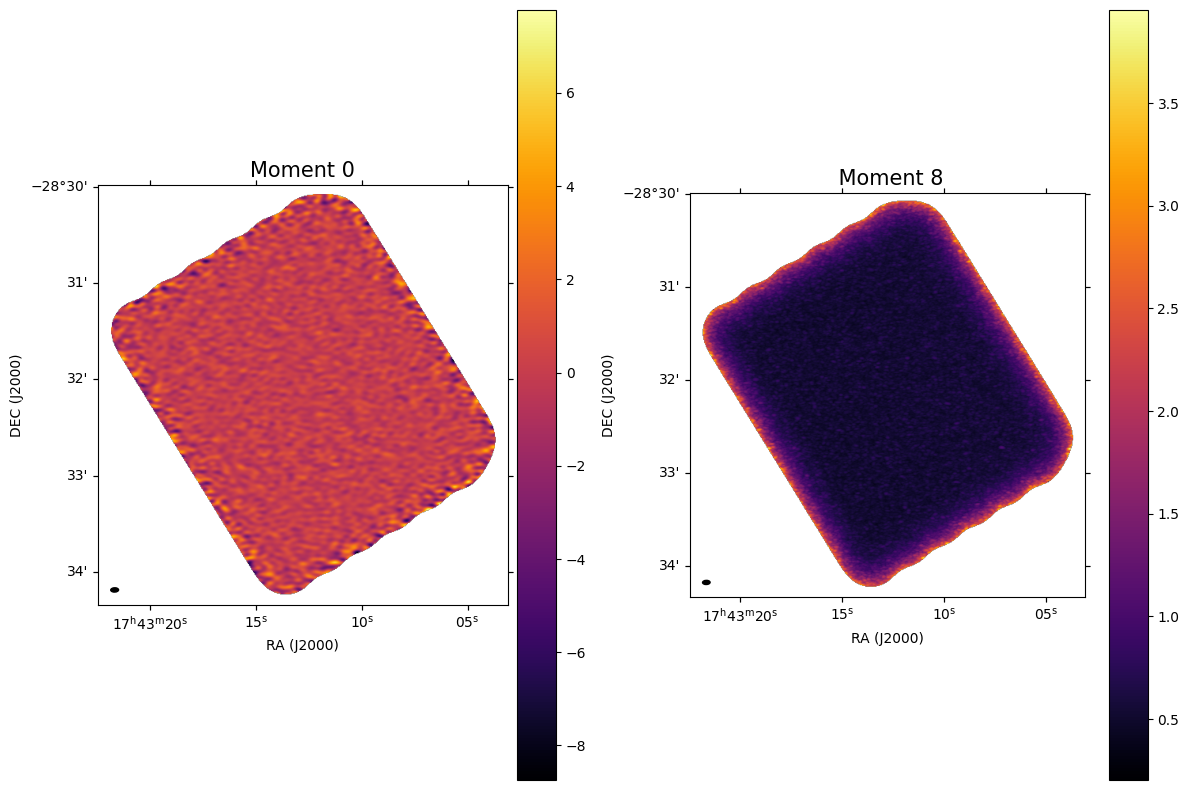

In [98]:
wcs_2d = mom0.wcs.celestial
fig = plt.figure(figsize=(14,10))
ax0 = fig.add_subplot(1, 2, 1, projection=wcs_2d)
ax1 = fig.add_subplot(1, 2, 2, projection=wcs_2d)

img0= ax0.imshow(mom0.value, origin='lower',cmap = 'inferno')
img1 = ax1.imshow(mom8.value, origin='lower',cmap = 'inferno')

ax0.set_title('Moment 0',size = 15)
ax1.set_title(' Moment 8',size = 15)
ax0.set_xlabel('RA (J2000)')
ax0.set_ylabel('DEC (J2000)')
ax1.set_xlabel('RA (J2000)')
ax1.set_ylabel('DEC (J2000)')
add_beam(ax0,
         header=cube.header,
         facecolor='black',
         edgecolor = 'black')

add_beam(ax1,
         header=cube.header,
         facecolor='black',
         edgecolor = 'black')
cbar0 = fig.colorbar(img0, ax = ax0, pad = 0.02)
cbar1 = fig.colorbar(img1, ax = ax1 )
#plt.savefig('NGC1333-IRAS2A_mom0_mom8_cube.png', dpi=300, bbox_inches='tight')
plt.show()